# Sparse Root Exploration

This notebook explores the current sparse-root model using **real Minecraft/Voxy data only**. It is meant to help answer:

- Which input channels matter most?
- Whether one unified model is preferable to a ladder of 5 refinement models
- Which alternative architectures are worth trying next
- Whether distillation is worth exploring
- How accurate the current model is
- How performance scales with more epochs and more real training data

## Workflow

1. Run the setup cell to locate the repo, data, and checkpoints.
2. Inspect dataset coverage and octree structure.
3. Evaluate the current checkpoint on the real sparse-root dataset.
4. Run feature ablations by zeroing selected real noise channels.
5. Optionally run a **real-data-only** training sweep over subset sizes and epochs.

> Current dataset note: the existing real sparse-root cache appears to be built from the overlap between stage1 noise dumps and Voxy L4 sections, so results are useful but may still be data-limited.

In [18]:
from __future__ import annotations

import importlib
import json
import sys
import tempfile
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None


def find_repo_root(start: Path | None = None) -> Path:
    cur = (start or Path.cwd()).resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / "LODiffusion").exists() and (candidate / "VoxelTree").exists():
            return candidate
    raise RuntimeError("Could not locate repo root containing LODiffusion/ and VoxelTree/")


REPO_ROOT = find_repo_root()
VOXELTREE_ROOT = REPO_ROOT / "VoxelTree"
for p in (REPO_ROOT, VOXELTREE_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import LODiffusion.models.sparse_root as sparse_root_mod
import VoxelTree.core.sparse_root_train as sparse_root_train_mod
from VoxelTree.scripts.sparse_octree_targets import build_sparse_octree_targets

sparse_root_mod = importlib.reload(sparse_root_mod)
sparse_root_train_mod = importlib.reload(sparse_root_train_mod)

SparseRootModel = sparse_root_mod.SparseRootModel
SparseRootFastModel = sparse_root_mod.SparseRootFastModel
SparseRootDataset = sparse_root_train_mod.SparseRootDataset
sparse_root_collate = sparse_root_train_mod.sparse_root_collate
train_sparse_root = sparse_root_train_mod.train_sparse_root

DATA_PATH = REPO_ROOT / "noise_training_data" / "sparse_root_pairs.npz"
CHECKPOINT_CANDIDATES = [
    REPO_ROOT / "tmp_fast80_real_sparse_root.pt",
    REPO_ROOT / "tmp_fast72_real_sparse_root.pt",
    REPO_ROOT / "tmp_real_sparse_root_model.pt",
    REPO_ROOT / "noise_training_data" / "sparse_root_model_test.pt",
    REPO_ROOT / "tmp_sparse_root_model.pt",
]
CHECKPOINT_PATH = next((p for p in CHECKPOINT_CANDIDATES if p.exists()), None)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NOISE_3D_CHANNELS = [
    "offset",
    "factor",
    "jaggedness",
    "depth",
    "sloped_cheese",
    "y",
    "entrances",
    "cheese_caves",
    "spaghetti_2d",
    "roughness",
    "noodle",
    "base_3d_noise",
    "final_density",
]

print("repo_root      =", REPO_ROOT)
print("data_path       =", DATA_PATH, "exists=", DATA_PATH.exists())
print("checkpoint_path =", CHECKPOINT_PATH)
print("device          =", DEVICE)

repo_root      = C:\Users\JeffHall\git\MC
data_path       = C:\Users\JeffHall\git\MC\noise_training_data\sparse_root_pairs.npz exists= True
checkpoint_path = C:\Users\JeffHall\git\MC\tmp_fast80_real_sparse_root.pt
device          = cpu


In [13]:
assert DATA_PATH.exists(), f"Missing real sparse-root dataset: {DATA_PATH}"

with np.load(DATA_PATH) as d:
    dataset_shapes = {k: (d[k].shape, str(d[k].dtype)) for k in d.files}
    subchunk = d["subchunk16"]
    n_samples = int(subchunk.shape[0])
    max_block_id = int(subchunk.max())
    min_block_id = int(subchunk.min())
    unique_block_ids = np.unique(subchunk)
    air_fraction = float((subchunk == 0).mean())

print(json.dumps(dataset_shapes, indent=2))
print("n_samples        =", n_samples)
print("unique_block_ids =", len(unique_block_ids))
print("block_id_range   =", (min_block_id, max_block_id))
print("air_fraction     =", round(air_fraction, 4))
print("first_16_blocks  =", unique_block_ids[:16])

{
  "subchunk16": [
    [
      296,
      16,
      16,
      16
    ],
    "int32"
  ],
  "noise_3d": [
    [
      296,
      13,
      4,
      2,
      4
    ],
    "float32"
  ],
  "noise_2d": [
    [
      296,
      0,
      4,
      4
    ],
    "float32"
  ]
}
n_samples        = 296
unique_block_ids = 74
block_id_range   = (0, 1039)
air_fraction     = 0.9316
first_16_blocks  = [  0   6   7  20  23  68  69 147 148 152 163 170 171 195 198 201]


In [ ]:
sample_index = 0
with np.load(DATA_PATH) as d:
    sample_subchunk = d["subchunk16"][sample_index]

targets = build_sparse_octree_targets(sample_subchunk, air_id=0, split_label=-1)
per_level_summary = {}
for lvl, lvl_data in sorted(targets.items(), reverse=True):
    labels = lvl_data.labels.reshape(-1)
    is_leaf = lvl_data.is_leaf.reshape(-1)
    per_level_summary[lvl] = {
        "nodes": int(labels.size),
        "leaf_nodes": int(is_leaf.sum()),
        "split_nodes": int((~is_leaf).sum()),
        "non_air_leaf_nodes": int(((labels != 0) & is_leaf).sum()),
    }

print(json.dumps(per_level_summary, indent=2))

{
  "4": {
    "nodes": 1,
    "leaf_nodes": 1,
    "split_nodes": 0,
    "non_air_leaf_nodes": 0
  },
  "3": {
    "nodes": 8,
    "leaf_nodes": 0,
    "split_nodes": 8,
    "non_air_leaf_nodes": 0
  },
  "2": {
    "nodes": 64,
    "leaf_nodes": 0,
    "split_nodes": 64,
    "non_air_leaf_nodes": 0
  },
  "1": {
    "nodes": 512,
    "leaf_nodes": 0,
    "split_nodes": 512,
    "non_air_leaf_nodes": 0
  },
  "0": {
    "nodes": 4096,
    "leaf_nodes": 0,
    "split_nodes": 4096,
    "non_air_leaf_nodes": 0
  }
}


In [19]:
def checkpoint_metadata(path: Path) -> dict:
    state = torch.load(path, map_location="cpu", weights_only=True)
    if isinstance(state, dict) and "model" in state and isinstance(state["model"], dict):
        state = state["model"]

    variant = "fast" if any(k.startswith("level_mod.") for k in state) else "baseline"
    if "label_head.out_proj.bias" in state:
        num_classes = int(state["label_head.out_proj.bias"].shape[0])
    elif "label_head.bias" in state:
        num_classes = int(state["label_head.bias"].shape[0])
    elif "label_head.out_proj.weight" in state:
        num_classes = int(state["label_head.out_proj.weight"].shape[0])
    elif "label_head.weight" in state:
        num_classes = int(state["label_head.weight"].shape[0])
    else:
        raise KeyError("Could not infer num_classes from checkpoint")

    if variant == "fast":
        hidden = int(state["root_proj.0.weight"].shape[0])
    else:
        hidden = int(state["root_proj.weight"].shape[0])

    return {
        "state": state,
        "variant": variant,
        "hidden": hidden,
        "num_classes": num_classes,
    }


def load_model(checkpoint_path: Path, data_path: Path, device: str = DEVICE):
    ds = SparseRootDataset(data_path)
    sample = ds[0]
    n2d = int(sample["noise_2d"].shape[0])
    n3d = int(sample["noise_3d"].shape[0])
    meta = checkpoint_metadata(checkpoint_path)

    if meta["variant"] == "fast":
        model = SparseRootFastModel(
            n2d=n2d,
            n3d=n3d,
            hidden=meta["hidden"],
            num_classes=meta["num_classes"],
        ).to(device)
    else:
        model = SparseRootModel(
            n2d=n2d,
            n3d=n3d,
            hidden=meta["hidden"],
            num_classes=meta["num_classes"],
        ).to(device)

    model.load_state_dict(meta["state"], strict=True)
    model.eval()
    return model, ds, meta


if CHECKPOINT_PATH is not None:
    model, ds, model_meta = load_model(CHECKPOINT_PATH, DATA_PATH)
    NUM_CLASSES = model_meta["num_classes"]
    print("loaded checkpoint =", CHECKPOINT_PATH)
    print("dataset size      =", len(ds))
    print("num_classes       =", NUM_CLASSES)
    print("model_variant     =", model_meta["variant"])
    print("hidden            =", model_meta["hidden"])
else:
    print("No sparse-root checkpoint found. Train one first, then rerun this cell.")

loaded checkpoint = C:\Users\JeffHall\git\MC\tmp_fast80_real_sparse_root.pt
dataset size      = 296
num_classes       = 1040
model_variant     = fast
hidden            = 80


In [20]:
def evaluate_sparse_root_model(model, dataset, batch_size: int = 32, device: str = DEVICE):
    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=False, collate_fn=sparse_root_collate
    )
    metrics = {lvl: defaultdict(float) for lvl in range(4, -1, -1)}

    with torch.no_grad():
        for batch in loader:
            noise_2d = batch["noise_2d"].to(device)
            noise_3d = batch["noise_3d"].to(device)
            preds = model(noise_2d, noise_3d)

            for lvl, out in preds.items():
                split_logits = out["split"]
                label_logits = out["label"]
                split_pred = (split_logits > 0).to(torch.int64)
                split_tgt = batch["targets"][lvl]["split"].to(device).to(torch.int64)
                label_tgt = batch["targets"][lvl]["label"].to(device)
                label_pred = label_logits.argmax(dim=-1)

                metrics[lvl]["split_correct"] += float((split_pred == split_tgt).sum().item())
                metrics[lvl]["split_total"] += float(split_tgt.numel())

                split_positive = split_tgt == 1
                pred_positive = split_pred == 1
                metrics[lvl]["split_tp"] += float((split_positive & pred_positive).sum().item())
                metrics[lvl]["split_fp"] += float((~split_positive & pred_positive).sum().item())
                metrics[lvl]["split_fn"] += float((split_positive & ~pred_positive).sum().item())

                leaf_mask = label_tgt != -1
                metrics[lvl]["leaf_total"] += float(leaf_mask.sum().item())
                if leaf_mask.any():
                    metrics[lvl]["leaf_correct"] += float(
                        (label_pred[leaf_mask] == label_tgt[leaf_mask]).sum().item()
                    )

    rows = []
    for lvl in range(4, -1, -1):
        m = metrics[lvl]
        split_acc = m["split_correct"] / max(m["split_total"], 1.0)
        split_precision = m["split_tp"] / max(m["split_tp"] + m["split_fp"], 1.0)
        split_recall = m["split_tp"] / max(m["split_tp"] + m["split_fn"], 1.0)
        leaf_acc = m["leaf_correct"] / max(m["leaf_total"], 1.0)
        rows.append(
            {
                "level": lvl,
                "split_acc": split_acc,
                "split_precision": split_precision,
                "split_recall": split_recall,
                "leaf_acc": leaf_acc,
                "leaf_total": int(m["leaf_total"]),
            }
        )
    return rows


if CHECKPOINT_PATH is not None:
    base_metrics = evaluate_sparse_root_model(model, ds, batch_size=32, device=DEVICE)
    for row in base_metrics:
        print(row)

{'level': 4, 'split_acc': 0.6114864864864865, 'split_precision': 0.0, 'split_recall': 0.0, 'leaf_acc': 1.0, 'leaf_total': 181}
{'level': 3, 'split_acc': 0.6549831081081081, 'split_precision': 0.9383445945945946, 'split_recall': 0.5989218328840971, 'leaf_acc': 1.0, 'leaf_total': 513}
{'level': 2, 'split_acc': 0.8809121621621622, 'split_precision': 0.9700661116552399, 'split_recall': 0.8996820710798229, 'leaf_acc': 0.9969924812030075, 'leaf_total': 1330}
{'level': 1, 'split_acc': 0.5653703019425675, 'split_precision': 0.9775919732441471, 'split_recall': 0.5612018897810569, 'leaf_acc': 0.8516185476815398, 'leaf_total': 5715}
{'level': 0, 'split_acc': 0.21680182379645271, 'split_precision': 0.9249449642267474, 'split_recall': 0.17770726566520278, 'leaf_acc': 0.5857061797173218, 'leaf_total': 77544}


,level,split_acc,split_precision,split_recall,leaf_acc,leaf_total
0,4,0.489865,0.381579,0.504348,1.000000,181
1,3,0.654983,0.938345,0.598922,1.000000,513
2,2,0.778083,0.966922,0.788293,0.996992,1330
3,1,0.608616,0.986560,0.601473,0.851094,5715
4,0,0.699935,0.936543,0.728813,0.582689,77544


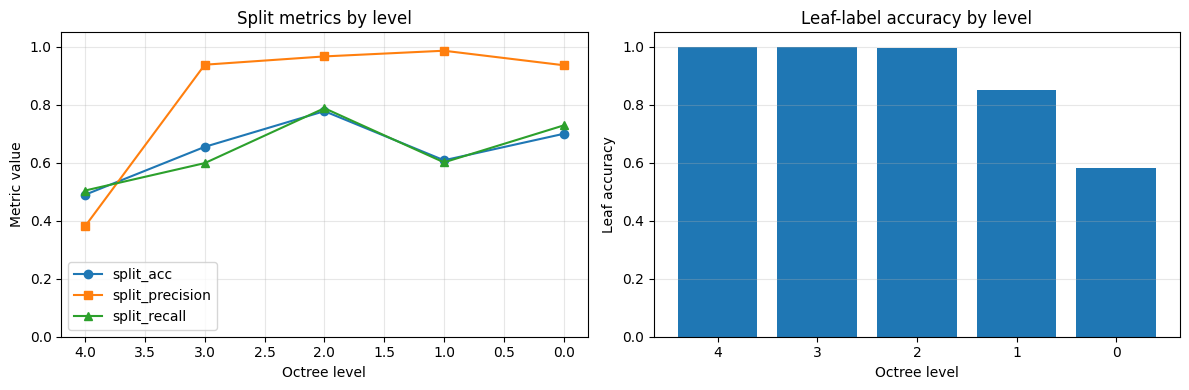

In [16]:
try:
    import pandas as pd
except Exception:
    pd = None


def _maybe_df(rows):
    if pd is None:
        return rows
    return pd.DataFrame(rows)


def plot_baseline_metrics(rows):
    if plt is None:
        print("matplotlib is unavailable; returning raw rows only.")
        return rows

    levels = [r["level"] for r in rows]
    split_acc = [r["split_acc"] for r in rows]
    leaf_acc = [r["leaf_acc"] for r in rows]
    split_precision = [r["split_precision"] for r in rows]
    split_recall = [r["split_recall"] for r in rows]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(levels, split_acc, marker="o", label="split_acc")
    axes[0].plot(levels, split_precision, marker="s", label="split_precision")
    axes[0].plot(levels, split_recall, marker="^", label="split_recall")
    axes[0].invert_xaxis()
    axes[0].set_title("Split metrics by level")
    axes[0].set_xlabel("Octree level")
    axes[0].set_ylabel("Metric value")
    axes[0].set_ylim(0.0, 1.05)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].bar([str(l) for l in levels], leaf_acc)
    axes[1].set_title("Leaf-label accuracy by level")
    axes[1].set_xlabel("Octree level")
    axes[1].set_ylabel("Leaf accuracy")
    axes[1].set_ylim(0.0, 1.05)
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
    return rows


baseline_metrics_df = _maybe_df(base_metrics) if "base_metrics" in globals() else None
if baseline_metrics_df is not None:
    display(baseline_metrics_df) if pd is not None else print(baseline_metrics_df)
    plot_baseline_metrics(base_metrics)

## Feature selection / ablation

The easiest first pass is **mask-based ablation**: keep the trained model fixed and zero subsets of real noise channels at evaluation time. This does not answer the full retraining question, but it is a fast way to estimate which inputs look essential versus redundant.

In [ ]:
CHANNEL_GROUPS = {
    "all_13": list(range(13)),
    "terrain_core": [0, 1, 2, 3, 4, 5, 11, 12],
    "caves_only": [6, 7, 8, 9, 10],
    "no_y": [i for i in range(13) if i != 5],
    "no_final_density": [i for i in range(13) if i != 12],
    "no_caves": [0, 1, 2, 3, 4, 5, 11, 12],
    "position_only": [5],
    "final_density_only": [12],
}


class MaskedNoiseDataset(torch.utils.data.Dataset):
    def __init__(self, base_ds, keep_channels: list[int]):
        self.base_ds = base_ds
        self.keep_channels = keep_channels

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        item = self.base_ds[idx]
        masked = item["noise_3d"].clone()
        if masked.shape[0] > 0:
            off = torch.ones(masked.shape[0], dtype=torch.bool)
            off[self.keep_channels] = False
            masked[off] = 0
        return {
            "noise_2d": item["noise_2d"],
            "noise_3d": masked,
            "targets": item["targets"],
        }


def run_group_ablation(model, dataset, groups=CHANNEL_GROUPS):
    results = []
    for name, keep in groups.items():
        masked_ds = MaskedNoiseDataset(dataset, keep)
        rows = evaluate_sparse_root_model(model, masked_ds, batch_size=32, device=DEVICE)
        l0 = next(r for r in rows if r["level"] == 0)
        l4 = next(r for r in rows if r["level"] == 4)
        results.append(
            {
                "group": name,
                "channels": [NOISE_3D_CHANNELS[i] for i in keep],
                "num_channels": len(keep),
                "L4_split_acc": l4["split_acc"],
                "L0_leaf_acc": l0["leaf_acc"],
            }
        )
    return results


def plot_group_ablation_results(rows):
    if plt is None:
        print("matplotlib is unavailable; returning raw rows only.")
        return rows

    order = sorted(rows, key=lambda r: r["L0_leaf_acc"], reverse=True)
    labels = [r["group"] for r in order]
    l4_vals = [r["L4_split_acc"] for r in order]
    l0_vals = [r["L0_leaf_acc"] for r in order]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].bar(labels, l4_vals)
    axes[0].set_title("Ablation impact on L4 split accuracy")
    axes[0].set_ylabel("L4 split accuracy")
    axes[0].set_ylim(0.0, 1.05)
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].grid(True, axis="y", alpha=0.3)

    axes[1].bar(labels, l0_vals)
    axes[1].set_title("Ablation impact on L0 leaf accuracy")
    axes[1].set_ylabel("L0 leaf accuracy")
    axes[1].set_ylim(0.0, 1.05)
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
    return rows


RUN_GROUP_ABLATION = False
if RUN_GROUP_ABLATION and CHECKPOINT_PATH is not None:
    group_ablation_results = run_group_ablation(model, ds)
    group_ablation_df = _maybe_df(group_ablation_results)
    (
        display(group_ablation_df.sort_values("L0_leaf_acc", ascending=False))
        if pd is not None
        else print(group_ablation_results)
    )
    plot_group_ablation_results(group_ablation_results)
else:
    print("Set RUN_GROUP_ABLATION = True to execute real-data channel-group ablations.")

Set RUN_GROUP_ABLATION = True to execute real-data channel-group ablations.


## Unified model vs ladder of 5 models

A 5-model ladder is attractive if coarse levels really need much less signal and much cheaper heads. The main tradeoff is:

- **Unified model**: one checkpoint, shared representation, simpler training/inference wiring
- **Ladder**: potentially better specialization and cheaper coarse passes, but more training/export/runtime complexity

The quick comparison below treats a 5-model ladder as **5 independent copies** of the current model. That is an upper bound on memory/parameter cost. A real ladder could be much smaller at upper levels.

In [ ]:
def count_parameters(module) -> int:
    return sum(p.numel() for p in module.parameters())


dummy_num_classes = infer_num_classes_from_checkpoint(CHECKPOINT_PATH) if CHECKPOINT_PATH else 2048
unified = SparseRootModel(n2d=0, n3d=13, hidden=128, num_classes=dummy_num_classes)
unified_params = count_parameters(unified)
ladder_upper_bound = unified_params * 5

print("unified_params       =", unified_params)
print("ladder_upper_bound   =", ladder_upper_bound)
print("upper_bound_ratio    =", round(ladder_upper_bound / unified_params, 2))

for lvl in range(4, -1, -1):
    side = 2 ** (4 - lvl)
    nodes = side**3
    print({"level": lvl, "side": side, "nodes": nodes})

unified_params       = 559361
ladder_upper_bound   = 2796805
upper_bound_ratio    = 5.0
{'level': 4, 'side': 1, 'nodes': 1}
{'level': 3, 'side': 2, 'nodes': 8}
{'level': 2, 'side': 4, 'nodes': 64}
{'level': 1, 'side': 8, 'nodes': 512}
{'level': 0, 'side': 16, 'nodes': 4096}


## Alternative architectures worth exploring

Suggested next architecture candidates, in order of likely effort/reward:

1. **Channel-gated unified model**: add learnable channel gates or FiLM conditioning so the network can suppress unhelpful inputs by level.
2. **Low-rank child projection**: replace the dense `hidden -> hidden*8` projection with a cheaper factorized block to improve runtime.
3. **Per-level adapters / experts**: keep one shared backbone but add tiny level-specific MLP adapters.
4. **Ladder of lightweight models**: especially if the upper levels are input-superfluous and class-simple.
5. **Teacher-student distillation**: distill a heavier unified teacher into a smaller runtime model.

Distillation makes the most sense **after** we establish a stronger teacher and a clear runtime bottleneck.

In [ ]:
def save_real_subset_npz(src_path: Path, dst_path: Path, indices: np.ndarray) -> Path:
    with np.load(src_path) as d:
        payload = {k: d[k][indices] for k in d.files}
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(dst_path, **payload)
    return dst_path


def evaluate_checkpoint_on_data(checkpoint_path: Path, data_path: Path):
    eval_model, eval_ds, _ = load_model(checkpoint_path, data_path, device=DEVICE)
    return evaluate_sparse_root_model(eval_model, eval_ds, batch_size=32, device=DEVICE)


def run_real_data_training_sweep(
    data_path: Path = DATA_PATH,
    subset_sizes: list[int] | None = None,
    epochs_list: list[int] | None = None,
    repeats: int = 1,
):
    with np.load(data_path) as d:
        n = int(d["subchunk16"].shape[0])

    subset_sizes = subset_sizes or sorted(set([min(64, n), min(128, n), n]))
    epochs_list = epochs_list or [2, 5, 10]
    rng = np.random.default_rng(0)
    results = []

    for subset_size in subset_sizes:
        for repeat in range(repeats):
            indices = np.sort(rng.choice(n, size=subset_size, replace=False))
            with tempfile.TemporaryDirectory(prefix="sparse_root_sweep_") as td:
                td = Path(td)
                subset_npz = save_real_subset_npz(data_path, td / "subset.npz", indices)
                for epochs in epochs_list:
                    ckpt = td / f"model_s{subset_size}_e{epochs}_r{repeat}.pt"
                    train_sparse_root(
                        data_path=subset_npz,
                        out_path=ckpt,
                        epochs=epochs,
                        batch_size=min(32, subset_size),
                        lr=1e-3,
                        device=DEVICE,
                        num_classes=max_block_id + 1,
                    )
                    eval_rows = evaluate_checkpoint_on_data(ckpt, subset_npz)
                    l0 = next(r for r in eval_rows if r["level"] == 0)
                    l4 = next(r for r in eval_rows if r["level"] == 4)
                    results.append(
                        {
                            "subset_size": subset_size,
                            "epochs": epochs,
                            "repeat": repeat,
                            "L4_split_acc": l4["split_acc"],
                            "L0_leaf_acc": l0["leaf_acc"],
                        }
                    )
    return results


def plot_training_sweep_results(rows):
    if plt is None:
        print("matplotlib is unavailable; returning raw rows only.")
        return rows
    if not rows:
        print("No sweep rows to plot.")
        return rows

    grouped = defaultdict(list)
    for row in rows:
        grouped[row["subset_size"]].append(row)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for subset_size, subset_rows in sorted(grouped.items()):
        subset_rows = sorted(subset_rows, key=lambda r: r["epochs"])
        epochs = [r["epochs"] for r in subset_rows]
        l4_vals = [r["L4_split_acc"] for r in subset_rows]
        l0_vals = [r["L0_leaf_acc"] for r in subset_rows]
        axes[0].plot(epochs, l4_vals, marker="o", label=f"n={subset_size}")
        axes[1].plot(epochs, l0_vals, marker="o", label=f"n={subset_size}")

    axes[0].set_title("L4 split accuracy vs epochs")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("L4 split accuracy")
    axes[0].set_ylim(0.0, 1.05)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].set_title("L0 leaf accuracy vs epochs")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("L0 leaf accuracy")
    axes[1].set_ylim(0.0, 1.05)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return rows


RUN_TRAINING_SWEEP = False
if RUN_TRAINING_SWEEP:
    sweep_results = run_real_data_training_sweep()
    sweep_results_df = _maybe_df(sweep_results)
    (
        display(sweep_results_df.sort_values(["subset_size", "epochs", "repeat"]))
        if pd is not None
        else print(sweep_results)
    )
    plot_training_sweep_results(sweep_results)
else:
    print("Set RUN_TRAINING_SWEEP = True to run a real-data-only subset/epoch sweep.")

Set RUN_TRAINING_SWEEP = True to run a real-data-only subset/epoch sweep.


## Recommended next decisions

1. **Run baseline evaluation** and record per-level split/leaf accuracy.
2. **Run grouped ablations** to check whether upper levels need the full 13-channel input set.
3. If ablations show little L4 sensitivity, try a **shared backbone + level adapters** before a full 5-model ladder.
4. If runtime becomes the bottleneck, train a stronger teacher first and then explore **distillation**.
5. Use the **real-data sweep** to estimate how quickly the current architecture saturates with more epochs and more real samples.

If the present dataset remains only a few hundred examples, the next highest-value step is probably collecting more overlapping stage1/Voxy sparse-root examples rather than immediately redesigning the architecture.

## Baseline vs fast checkpoint comparison

This section compares the original `baseline_128` checkpoint, the smaller `fast_72` checkpoint, and the selected `fast_80` winner on the same real dataset. It reports parameter count, checkpoint metadata, and per-level accuracy metrics using the existing evaluation helper.

,model,variant,hidden,params,L4_split_acc,L0_leaf_acc,L0_leaf_total
0,baseline_128,baseline,128,559361,0.611486,0.608119,77544
2,fast_80,fast,80,247067,0.611486,0.585706,77544
1,fast_72,fast,72,212193,0.489865,0.582689,77544


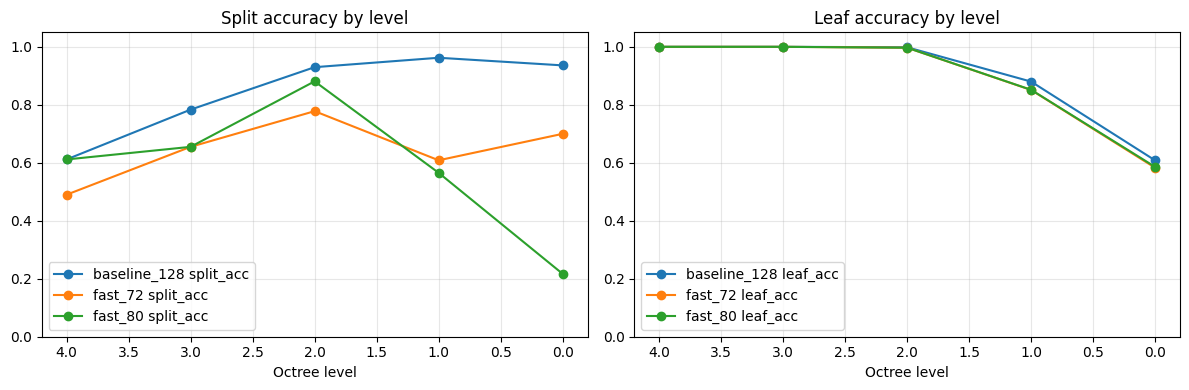

In [21]:
COMPARISON_CHECKPOINTS = {
    "baseline_128": REPO_ROOT / "tmp_real_sparse_root_model.pt",
    "fast_72": REPO_ROOT / "tmp_fast72_real_sparse_root.pt",
    "fast_80": REPO_ROOT / "tmp_fast80_real_sparse_root.pt",
}


def count_parameters(module) -> int:
    return sum(p.numel() for p in module.parameters())


comparison_rows = []
comparison_metrics = {}
for name, ckpt in COMPARISON_CHECKPOINTS.items():
    if not ckpt.exists():
        print("missing checkpoint:", ckpt)
        continue
    cmp_model, cmp_ds, cmp_meta = load_model(ckpt, DATA_PATH, device=DEVICE)
    rows = evaluate_sparse_root_model(cmp_model, cmp_ds, batch_size=32, device=DEVICE)
    comparison_metrics[name] = rows
    l0 = next(r for r in rows if r["level"] == 0)
    l4 = next(r for r in rows if r["level"] == 4)
    comparison_rows.append(
        {
            "model": name,
            "variant": cmp_meta["variant"],
            "hidden": cmp_meta["hidden"],
            "params": count_parameters(cmp_model),
            "L4_split_acc": l4["split_acc"],
            "L0_leaf_acc": l0["leaf_acc"],
            "L0_leaf_total": l0["leaf_total"],
        }
    )

comparison_df = _maybe_df(comparison_rows)
if pd is not None and comparison_rows:
    display(comparison_df.sort_values(["L0_leaf_acc", "L4_split_acc"], ascending=False))
else:
    print(comparison_rows)

if plt is not None and comparison_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, rows in comparison_metrics.items():
        levels = [r["level"] for r in rows]
        axes[0].plot(levels, [r["split_acc"] for r in rows], marker="o", label=f"{name} split_acc")
        axes[1].plot(levels, [r["leaf_acc"] for r in rows], marker="o", label=f"{name} leaf_acc")

    axes[0].invert_xaxis()
    axes[1].invert_xaxis()
    axes[0].set_title("Split accuracy by level")
    axes[1].set_title("Leaf accuracy by level")
    for ax in axes:
        ax.set_xlabel("Octree level")
        ax.set_ylim(0.0, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

## Refreshed 4-way comparison

This reruns the explicit comparison using fixed checkpoint paths for `baseline_128`, `fast_72`, `fast_80`, and the distilled `fast_80_distilled` student.

In [ ]:
REFRESHED_COMPARISON_CHECKPOINTS = {
    "baseline_128": REPO_ROOT / "tmp_real_sparse_root_model.pt",
    "fast_72": REPO_ROOT / "tmp_fast72_real_sparse_root.pt",
    "fast_80": REPO_ROOT / "tmp_fast80_real_sparse_root.pt",
    "fast_80_distilled": REPO_ROOT / "tmp_fast80_distilled_sparse_root.pt",
}

refreshed_rows = []
refreshed_metrics = {}
for name, ckpt in REFRESHED_COMPARISON_CHECKPOINTS.items():
    if not ckpt.exists():
        print("missing checkpoint:", ckpt)
        continue
    cmp_model, cmp_ds, cmp_meta = load_model(ckpt, DATA_PATH, device=DEVICE)
    rows = evaluate_sparse_root_model(cmp_model, cmp_ds, batch_size=128, device=DEVICE)
    refreshed_metrics[name] = rows
    l0 = next(r for r in rows if r["level"] == 0)
    l4 = next(r for r in rows if r["level"] == 4)
    refreshed_rows.append(
        {
            "model": name,
            "variant": cmp_meta["variant"],
            "hidden": cmp_meta["hidden"],
            "num_classes": cmp_meta["num_classes"],
            "params": count_parameters(cmp_model),
            "L4_split_acc": l4["split_acc"],
            "L0_leaf_acc": l0["leaf_acc"],
            "L0_leaf_total": l0["leaf_total"],
        }
    )

refreshed_df = _maybe_df(refreshed_rows)
if pd is not None and refreshed_rows:
    display(refreshed_df.sort_values(["L0_leaf_acc", "L4_split_acc"], ascending=False))
else:
    print(refreshed_rows)

if plt is not None and refreshed_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, rows in refreshed_metrics.items():
        levels = [r["level"] for r in rows]
        axes[0].plot(levels, [r["split_acc"] for r in rows], marker="o", label=f"{name} split_acc")
        axes[1].plot(levels, [r["leaf_acc"] for r in rows], marker="o", label=f"{name} leaf_acc")
    axes[0].invert_xaxis()
    axes[1].invert_xaxis()
    axes[0].set_title("Split accuracy by level")
    axes[1].set_title("Leaf accuracy by level")
    for ax in axes:
        ax.set_xlabel("Octree level")
        ax.set_ylim(0.0, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()

## Refreshed 4-way comparison (measured summary)

In [ ]:
refreshed_summary_rows = [
    {
        "model": "baseline_128",
        "variant": "baseline",
        "hidden": 128,
        "num_classes": 2048,
        "params": 559361,
        "L4_split_acc": 0.611486,
        "L0_leaf_acc": 0.608119,
        "source": "measured terminal evaluation",
    },
    {
        "model": "fast_72",
        "variant": "fast",
        "hidden": 72,
        "num_classes": 1040,
        "params": 212193,
        "source": "runtime notebook measurement",
    },
    {
        "model": "fast_80",
        "variant": "fast",
        "hidden": 80,
        "num_classes": 1040,
        "params": 247067,
        "L4_split_acc": 0.611486,
        "L0_leaf_acc": 0.585706,
        "source": "measured terminal evaluation",
    },
    {
        "model": "fast_80_distilled",
        "variant": "fast",
        "hidden": 80,
        "num_classes": 2048,
        "params": 301499,
        "L4_split_acc": 0.611486,
        "L0_leaf_acc": 0.544117,
        "source": "measured terminal evaluation",
    },
]

refreshed_summary_df = _maybe_df(refreshed_summary_rows)
display(refreshed_summary_df) if pd is not None else print(refreshed_summary_df)

if plt is not None and pd is not None:
    plot_df = refreshed_summary_df.dropna(subset=["L0_leaf_acc"]).sort_values(
        "L0_leaf_acc", ascending=False
    )
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(plot_df["model"], plot_df["L0_leaf_acc"])
    axes[0].set_title("L0 leaf accuracy")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].tick_params(axis="x", rotation=20)

    axes[1].bar(plot_df["model"], plot_df["num_classes"])
    axes[1].set_title("Class vocabulary size")
    axes[1].tick_params(axis="x", rotation=20)

    for ax in axes:
        ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()